# PPSeq synthetic data demo

Testing PPSeq on synthetic data with dynamic background rate.

## Setup


In [1]:
try:
    import ppseq
except Exception:
    %pip install -q git+https://github.com/lindermanlab/ppseq-pytorch.git@main
    import ppseq


In [2]:
import matplotlib.pyplot as plt
import torch

from ppseq.plotting import plot_model, color_plot
from ppseq.model import PPSeq
from generate_data import generate_data_glm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('Could not find a GPU. Defaulting to CPU instead.')


Could not find a GPU. Defaulting to CPU instead.


## Generate synthetic data


In [4]:
# Use GLM-based generator with dynamic background
N, T, K, D, P = 50, 1000, 2, 10, 4
seed = 1  # set to None for different random draws each run
num_segments = 8
# Dense segments get positive offsets in log-rate; sparse segments get negative.
# Tune magnitude ranges to control contrast between dense and sparse periods.
dense_strength_range = (0.4, 1.0)
sparse_strength_range = (0.2, 0.8)
X, lambdas, alpha, beta, X_cov, true_a, true_w, lambda_bg = generate_data_glm(
    N=N, T=T, K=K, D=D, P=P, seed=seed,
    num_segments=num_segments,
    dense_strength_range=dense_strength_range,
    sparse_strength_range=sparse_strength_range,
)

# Move to device
data = X.to(device)
num_neurons, num_timesteps = data.shape


## Construct a PPSeq model


In [5]:
torch.manual_seed(0)
model = PPSeq(num_templates=K,
              num_neurons=num_neurons,
              template_duration=D,
              alpha_a0=1.5,
              beta_a0=0.2,
              alpha_b0=1,
              beta_b0=0.1,
              alpha_t0=1.2,
              beta_t0=0.1,
              )


Could not find a GPU. Defaulting to CPU instead.


In [6]:
lps, amplitudes = model.fit(data, num_iter=100)


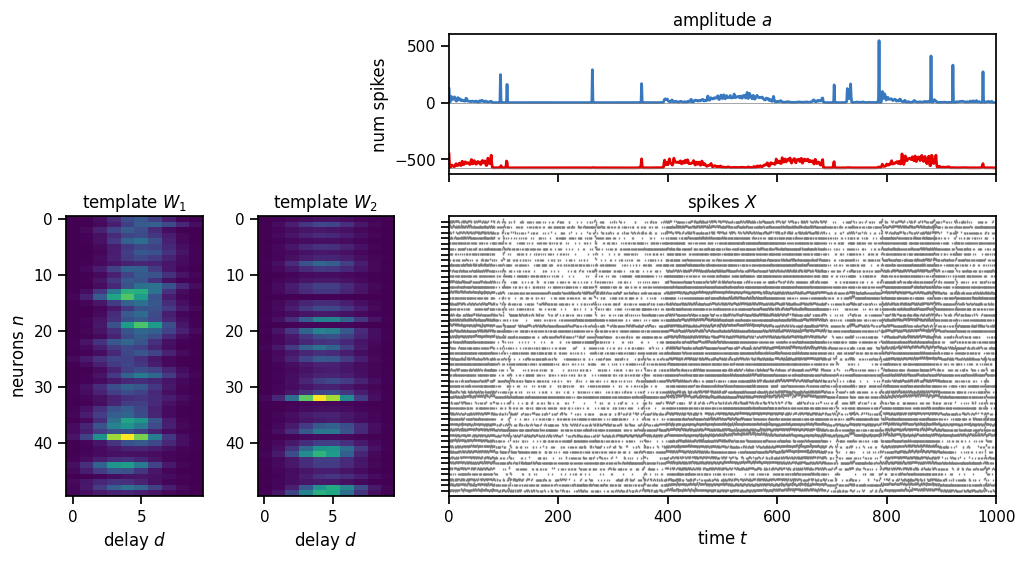

In [7]:
plot_model(model.templates.cpu(),
           amplitudes.cpu(),
           data.cpu(),
           spc=.33)

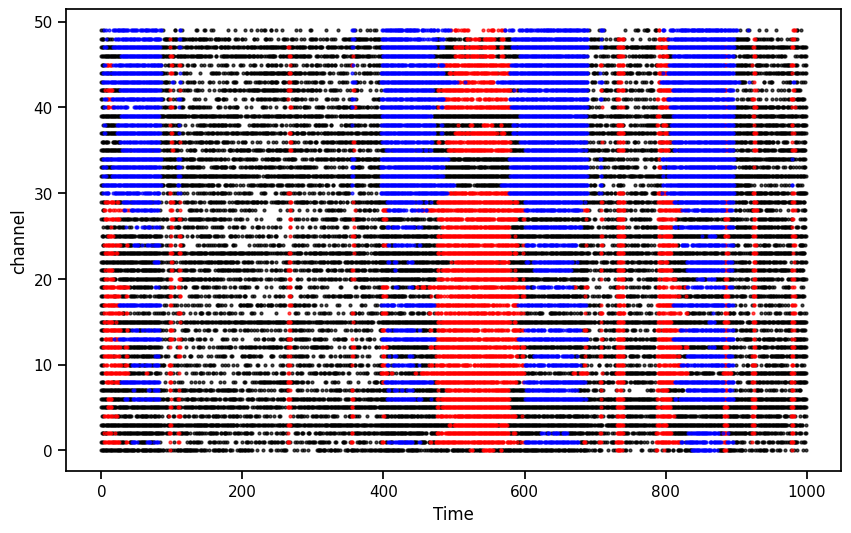

In [8]:
color_plot(data.cpu(),
           model,
           amplitudes.cpu(),
           )

Text(0, 0.5, 'log likelihood')

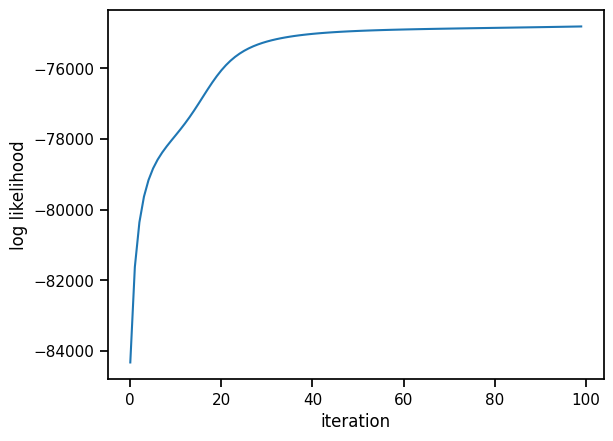

In [9]:
plt.plot(lps.cpu())
plt.xlabel("iteration")
plt.ylabel("log likelihood")


## Conclusion

This notebook demonstrates PPSeq on synthetic data generated in `notebooks/generate_data.py`. For real datasets or GLM-based backgrounds, adjust the generator and model accordingly.
